In [1]:
import sys, os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization, Flatten, Dense, Dropout, Input
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras.optimizers import Adam

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from data_processing import MelDataManager

data_folder = "../../data/genres_original"
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock']

2026-01-10 21:31:25.193886: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# --- GPU + Mixed Precision Setup (start cell) ---
from tensorflow.keras import mixed_precision

# Hide unnecessary info
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Check if GPU is loaded
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {gpus[0].name}")
else:
    print("GPU NOT detected — TensorFlow will run on CPU")

mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision enabled (mixed_float16)")

print(f"TensorFlow version: {tf.__version__}")
print(f"Compute dtype: {mixed_precision.global_policy().compute_dtype}")
print(f"Variable dtype: {mixed_precision.global_policy().variable_dtype}")

GPU detected: /physical_device:GPU:0
Mixed precision enabled (mixed_float16)
TensorFlow version: 2.20.0
Compute dtype: float16
Variable dtype: float32


In [3]:
mgr = MelDataManager(
    data_folder=data_folder,
    classes=classes,
    cache_path="../../data/processed/melspec_cache.npz",
    target_shape=(150, 150),
    chunk_duration=4,
    overlap_duration=2,
)

data, labels = mgr.load_or_build_cache()
print(f"Data shape: {data.shape}")
print(f"Labels shape (before one-hot): {labels.shape}")

Loaded cached data from ../../data/processed/melspec_cache.npz
Data shape: (14975, 150, 150, 1)
Labels shape (before one-hot): (14975,)


In [4]:
labels = mgr.one_hot()
print(f"Labels shape (one-hot): {labels.shape}")

Labels shape (one-hot): (14975, 10)


In [5]:
X_train, X_test, Y_train, Y_test = mgr.split(test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (11980, 150, 150, 1)
X_test shape: (2995, 150, 150, 1)
Y_train shape: (11980, 10)
Y_test shape: (2995, 10)


In [6]:
# Zdefiniuj kluczowe stałe
INPUT_SHAPE = (150, 150, 1) # Wymiar Twoich spektrogramów (Wysokość, Szerokość, Kanały)
NUM_CLASSES = 10           # Liczba gatunków muzycznych

# Użyj modelu Sequential
CNN_2 = Sequential([
    # Warstwa wejściowa (Input Layer)
    Input(shape=INPUT_SHAPE),

    # Blok 1: Conv1 + Pool1 + BatchNorm1
    # Conv1: 32 filtry, rozmiar jądra 3x3, padding='same'
    Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu', name='conv1'),
    # BatchNorm1: Normalizacja wsadowa (PyTorch 'bn1')
    BatchNormalization(name='bn1'),
    # Pool1: Redukcja wymiaru 2x2, stride=2
    MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='pool1'),

    # Blok 2: Conv2 + Pool2 + BatchNorm2
    # Conv2: 64 filtry, rozmiar jądra 3x3, padding='same'
    Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu', name='conv2'),
    # BatchNorm2: Normalizacja wsadowa (PyTorch 'bn2')
    BatchNormalization(name='bn2'),
    # Pool2: Redukcja wymiaru 2x2, stride=2
    MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='pool2'),

    # Przekształcanie do wektora dla warstw gęstych
    Flatten(name='flatten'),

    # Warstwy Gęste (Fully Connected)
    # FC1: 128 jednostek (PyTorch 'fc1')
    Dense(units=128, activation='relu', name='fc1'),
    # Dropout: Prawdopodobieństwo 0.5 (PyTorch 'dropout1')
    Dropout(rate=0.5, name='dropout1'),

    # FC2 (Wyjściowa): 10 jednostek, 'softmax' do klasyfikacji (PyTorch 'fc2')
    Dense(units=NUM_CLASSES, activation='softmax', name='fc2')
])

# Wyświetl podsumowanie modelu
CNN_2.summary()

I0000 00:00:1768077217.850300   18165 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 150, 150, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 75, 75, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │    11,214,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,235,466 (42.86 MB)

 Trainable params: 11,235,274 (42.86 MB)

 Non-trainable params: 192 (768.00 B)

In [7]:
CNN_2.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
if 'X_train' in locals() and 'Y_train' in locals():
    print("\nRozpoczynanie treningu (30 epok, batch_size=32)...")
    training_history = CNN_2.fit(
        X_train, Y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=32,
        verbose=1
    )
    print("\nTrening zakończony!")
else:
    print("\n--- UWAGA: Dane treningowe (X_train, Y_train) nie są dostępne. ---")
    print("Nie można uruchomić model.fit. Upewnij się, że wykonałeś preprocessing i podział danych (komórki 1-8).")


Rozpoczynanie treningu (30 epok, batch_size=32)...


2026-01-10 21:33:53.049024: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 862560000 exceeds 10% of free system memory.
2026-01-10 21:33:55.082232: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 862560000 exceeds 10% of free system memory.


Epoch 1/30


2026-01-10 21:34:04.310104: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fa4780048b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-10 21:34:04.310172: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-01-10 21:34:05.657466: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-10 21:34:07.853524: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-01-10 21:34:09.090204: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-10 21:34:26.

  3/300 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.1285 - loss: 3.8674   

I0000 00:00:1768077300.398058   19231 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


300/300 ━━━━━━━━━━━━━━━━━━━━ 90s 89ms/step - accuracy: 0.2423 - loss: 2.3423 - val_accuracy: 0.3644 - val_loss: 1.8721
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.3408 - loss: 1.9058 - val_accuracy: 0.4386 - val_loss: 1.6579
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4206 - loss: 1.6999 - val_accuracy: 0.5246 - val_loss: 1.4598
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4955 - loss: 1.4684 - val_accuracy: 0.5580 - val_loss: 1.3616
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5481 - loss: 1.3236 - val_accuracy: 0.5864 - val_loss: 1.3113
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5959 - loss: 1.1865 - val_accuracy: 0.6198 - val_loss: 1.1855
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6300 - loss: 1.0867 - val_accuracy: 0.6469 - val_loss: 1.1506
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.6712 - loss: 0.9665 - val_accuracy: 0.6

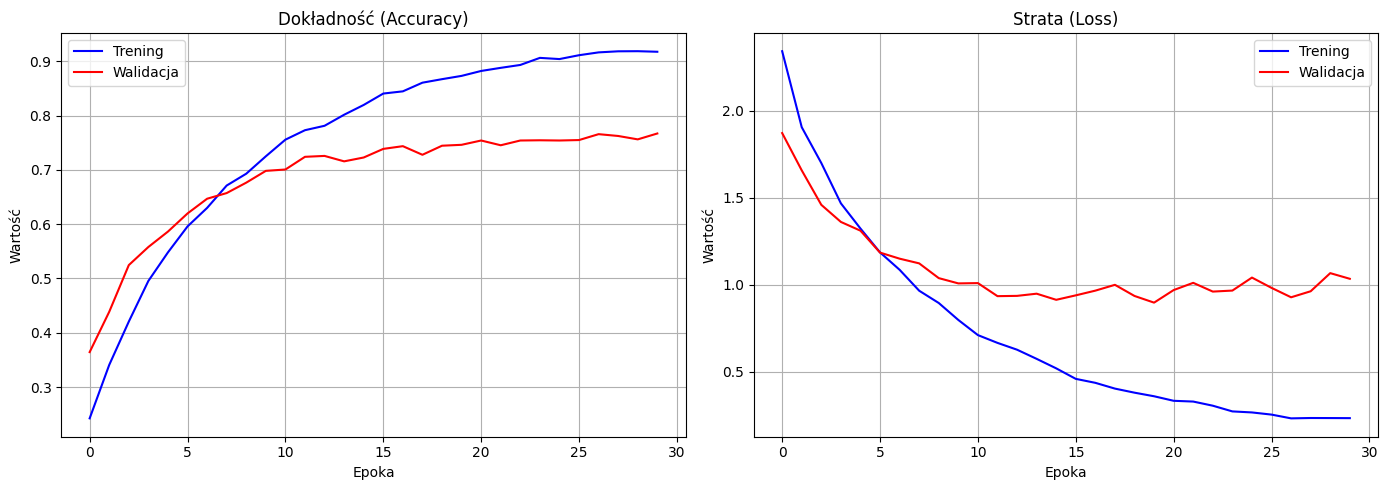

In [9]:
acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']
loss = training_history.history['loss']
val_loss = training_history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(acc, label='Trening', color='blue')
ax1.plot(val_acc, label='Walidacja', color='red')
ax1.set_title('Dokładność (Accuracy)')
ax1.set_xlabel('Epoka')
ax1.set_ylabel('Wartość')
ax1.legend()
ax1.grid(True)

ax2.plot(loss, label='Trening', color='blue')
ax2.plot(val_loss, label='Walidacja', color='red')
ax2.set_title('Strata (Loss)')
ax2.set_xlabel('Epoka')
ax2.set_ylabel('Wartość')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Ewaluacja na zbiorze testowym
test_loss, test_acc = CNN_2.evaluate(X_test, Y_test, verbose=1)
print(f"\nDokładność na zbiorze testowym: {test_acc:.2%}")
print(f"Strata na zbiorze testowym: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.7659 - loss: 1.0382

Dokładność na zbiorze testowym: 76.59%
Strata na zbiorze testowym: 1.0382


94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step


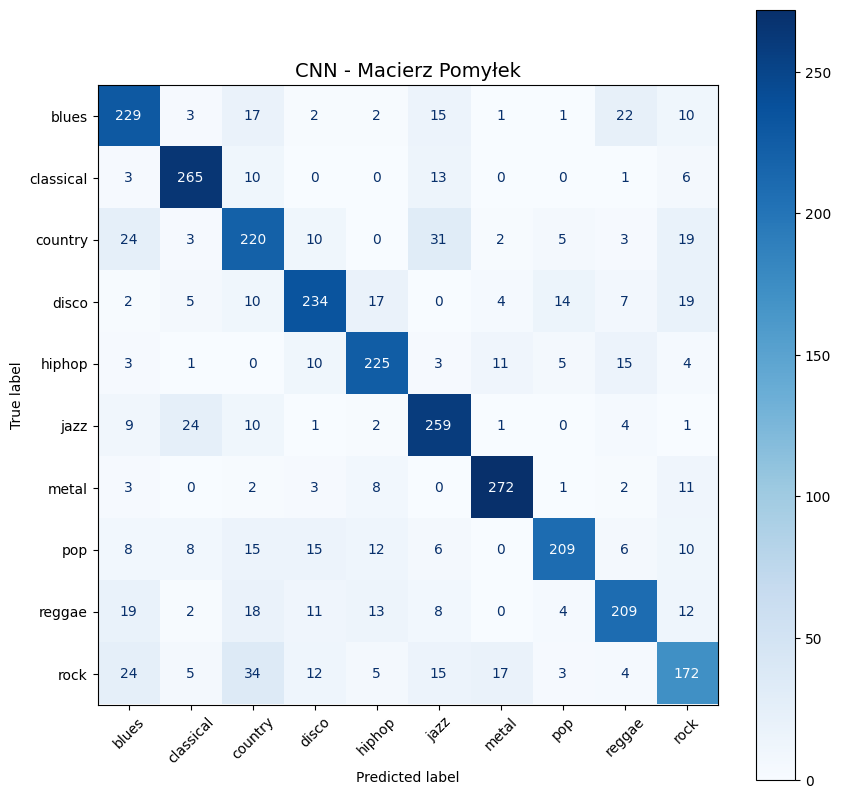


Raport klasyfikacji:
              precision    recall  f1-score   support

       blues       0.71      0.76      0.73       302
   classical       0.84      0.89      0.86       298
     country       0.65      0.69      0.67       317
       disco       0.79      0.75      0.77       312
      hiphop       0.79      0.81      0.80       277
        jazz       0.74      0.83      0.78       311
       metal       0.88      0.90      0.89       302
         pop       0.86      0.72      0.79       289
      reggae       0.77      0.71      0.73       296
        rock       0.65      0.59      0.62       291

    accuracy                           0.77      2995
   macro avg       0.77      0.77      0.77      2995
weighted avg       0.77      0.77      0.77      2995



In [12]:
Y_pred_proba = CNN_2.predict(X_test)
Y_pred_classes = np.argmax(Y_pred_proba, axis=1)
Y_true_classes = np.argmax(Y_test, axis=1)

cm = confusion_matrix(Y_true_classes, Y_pred_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(10, 10))
cm_display.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('CNN - Macierz Pomyłek', fontsize=14)
plt.xticks(rotation=45)
plt.show()

print("\nRaport klasyfikacji:")
print(classification_report(Y_true_classes, Y_pred_classes, target_names=classes))

In [ ]:
CNN_2.save('../models/CNN_2.keras')
print("Model zapisany jako: ../models/CNN_2.keras")

Model zapisany jako: ../models/CNN_2.keras


: 